In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

## 1) File paths and class map

In [16]:
DATA_DIR = Path("../data/raw")

FILES = {
    "rest/rest_stressed_20260406_170652.csv": "rest",
    "moderate/moderate_walking_20260407_120447.csv": "moderate",
    "moderate/moderate_stairs_20260411_224148.csv": "moderate",   
    "intense/intense_running_20260414_195242.csv": "intense",
    "intense/intense_squats_20260411_223205.csv": "intense",
}

LABEL_MAP = {
    "rest": 0,
    "moderate": 1,
    "intense": 2
}


## 2) Load and clean each file

In [17]:
def load_and_clean_csv(file_path, class_label):
    df = pd.read_csv(file_path)

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["activity"] = class_label

    numeric_cols = ["temp", "emg_raw", "emg_env", "emg_state", "ax", "ay", "az", "hr"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.loc[df["hr"] <= 0, "hr"] = np.nan

    df["hr"] = df["hr"].interpolate(limit_direction="both")
    df["hr"] = df["hr"].ffill().bfill()

    for col in numeric_cols:
        df[col] = df[col].interpolate(limit_direction="both")
        df[col] = df[col].ffill().bfill()

    df["acc_mag"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

    df["dt"] = df["timestamp"].diff().dt.total_seconds()
    median_dt = df["dt"].median()
    df["dt"] = df["dt"].fillna(median_dt if pd.notna(median_dt) else 1.0)

    return df

## 3) Load all files

In [18]:
all_dfs = []

for fname, cls in FILES.items():
    path = DATA_DIR / fname
    print(path)
    df = load_and_clean_csv(path, cls)
    df["source_file"] = fname
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

print(full_df.shape)
print(full_df[["source_file", "activity"]].drop_duplicates())
full_df.head()

..\data\raw\rest\rest_stressed_20260406_170652.csv
..\data\raw\moderate\moderate_walking_20260407_120447.csv
..\data\raw\moderate\moderate_stairs_20260411_224148.csv
..\data\raw\intense\intense_running_20260414_195242.csv
..\data\raw\intense\intense_squats_20260411_223205.csv
(1231, 14)
                                        source_file  activity
0            rest/rest_stressed_20260406_170652.csv      rest
331   moderate/moderate_walking_20260407_120447.csv  moderate
658    moderate/moderate_stairs_20260411_224148.csv  moderate
782     intense/intense_running_20260414_195242.csv   intense
1135     intense/intense_squats_20260411_223205.csv   intense


,timestamp,label,temp,emg_raw,emg_env,emg_state,ax,ay,az,hr,activity,acc_mag,dt,source_file
0,2026-04-06 17:07:15.063368,rest,29.87,47.0,14.0,0.0,16884.0,-524.0,720.0,106.0,rest,16907.466753,1.035213,rest/rest_stressed_20260406_170652.csv
1,2026-04-06 17:07:16.098730,rest,29.87,69.0,16.0,1.0,16952.0,-460.0,744.0,106.0,rest,16974.552719,1.035362,rest/rest_stressed_20260406_170652.csv
2,2026-04-06 17:07:17.132831,rest,29.87,53.0,15.0,0.0,16916.0,-436.0,692.0,105.0,rest,16935.761453,1.034101,rest/rest_stressed_20260406_170652.csv
3,2026-04-06 17:07:18.168232,rest,29.87,62.0,13.0,0.0,16872.0,-492.0,636.0,103.0,rest,16891.149872,1.035401,rest/rest_stressed_20260406_170652.csv
4,2026-04-06 17:07:19.202292,rest,29.94,55.0,14.0,0.0,16956.0,-508.0,700.0,101.0,rest,16978.044646,1.034060,rest/rest_stressed_20260406_170652.csv


## 4) Window feature extraction

In [19]:
WINDOW_SEC = 10
STEP_SEC = 10

def waveform_length(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return np.sum(np.abs(np.diff(x)))

def zero_crossings(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0
    x_centered = x - np.mean(x)
    return np.sum(np.diff(np.sign(x_centered)) != 0)

def slope_feature(x):
    x = np.asarray(x)
    if len(x) < 2:
        return 0.0
    return (x[-1] - x[0]) / len(x)

def extract_features_from_window(win):
    feats = {}

    # HR
    feats["hr_mean"] = win["hr"].mean()
    feats["hr_std"] = win["hr"].std()
    feats["hr_min"] = win["hr"].min()
    feats["hr_max"] = win["hr"].max()
    feats["hr_range"] = feats["hr_max"] - feats["hr_min"]

    # Temperature
    feats["temp_mean"] = win["temp"].mean()
    feats["temp_std"] = win["temp"].std()
    feats["temp_min"] = win["temp"].min()
    feats["temp_max"] = win["temp"].max()
    feats["temp_slope"] = slope_feature(win["temp"].values)

    # EMG
    feats["emg_raw_mean"] = win["emg_raw"].mean()
    feats["emg_raw_std"] = win["emg_raw"].std()
    feats["emg_env_mean"] = win["emg_env"].mean()
    feats["emg_env_std"] = win["emg_env"].std()
    feats["emg_rms"] = np.sqrt(np.mean(win["emg_raw"].values**2))
    feats["emg_mav"] = np.mean(np.abs(win["emg_raw"].values))
    feats["emg_wl"] = waveform_length(win["emg_raw"].values)
    feats["emg_zero_cross"] = zero_crossings(win["emg_raw"].values)
    feats["emg_state_mean"] = win["emg_state"].mean()

    # IMU axis stats
    for axis in ["ax", "ay", "az"]:
        feats[f"{axis}_mean"] = win[axis].mean()
        feats[f"{axis}_std"] = win[axis].std()
        feats[f"{axis}_min"] = win[axis].min()
        feats[f"{axis}_max"] = win[axis].max()

    # Magnitude stats
    feats["acc_mag_mean"] = win["acc_mag"].mean()
    feats["acc_mag_std"] = win["acc_mag"].std()
    feats["acc_mag_min"] = win["acc_mag"].min()
    feats["acc_mag_max"] = win["acc_mag"].max()
    feats["acc_mag_range"] = feats["acc_mag_max"] - feats["acc_mag_min"]
    feats["acc_mag_energy"] = np.mean(win["acc_mag"].values**2)

    # Jerk from magnitude
    if len(win) > 1:
        jerk = np.diff(win["acc_mag"].values)
        feats["jerk_mean"] = np.mean(np.abs(jerk))
        feats["jerk_std"] = np.std(jerk)
    else:
        feats["jerk_mean"] = 0.0
        feats["jerk_std"] = 0.0

    return feats

In [28]:
def build_windowed_dataset(df, window_sec=10, step_sec=10):
    rows = []

    for source_file, g in df.groupby("source_file"):
        g = g.sort_values("timestamp").reset_index(drop=True)

        start_time = g["timestamp"].min()
        end_time = g["timestamp"].max()

        t = start_time
        while t + pd.Timedelta(seconds=window_sec) <= end_time:
            w_end = t + pd.Timedelta(seconds=window_sec)
            win = g[(g["timestamp"] >= t) & (g["timestamp"] < w_end)].copy()

            # Require enough points
            if len(win) >= max(5, window_sec // 2):
                feats = extract_features_from_window(win)
                feats["label_name"] = win["activity"].iloc[0]
                feats["label"] = LABEL_MAP[win["activity"].iloc[0]]
                feats["source_file"] = source_file
                feats["window_start"] = t
                feats["window_end"] = w_end
                feats["n_samples"] = len(win)
                rows.append(feats)

            t += pd.Timedelta(seconds=step_sec)

    return pd.DataFrame(rows)

In [21]:
features_df = build_windowed_dataset(full_df, window_sec=WINDOW_SEC, step_sec=STEP_SEC)

print(features_df.shape)
print(features_df["label_name"].value_counts())
features_df.head()

(124, 45)
label_name
intense     45
moderate    45
rest        34
Name: count, dtype: int64


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
2,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9
3,122.300000,5.375872,114.0,129.0,15.0,25.968000,0.189021,25.69,26.25,-0.056000,...,18848.170897,4.017341e+08,13013.301236,13811.219595,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:47.519406,2026-04-14 19:53:57.519406,10
4,126.900000,0.994429,126.0,129.0,3.0,25.461000,0.139400,25.25,25.69,-0.044000,...,21599.531893,4.433055e+08,11563.092523,13163.102565,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:57.519406,2026-04-14 19:54:07.519406,10


## 5) Evaluation by file

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

drop_cols = ["label_name", "label", "source_file", "window_start", "window_end"]
X_all = features_df.drop(columns=drop_cols).fillna(0)
y_all = features_df["label"]
groups = features_df["source_file"]

unique_files = groups.unique()

all_preds = []
all_true = []
results = []

for test_file in unique_files:
    train_idx = groups != test_file
    test_idx = groups == test_file

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=8,
        min_samples_leaf=4,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "test_file": test_file,
        "n_test_windows": len(y_test),
        "accuracy": acc
    })

    all_true.extend(y_test.tolist())
    all_preds.extend(y_pred.tolist())

results_df = pd.DataFrame(results)
results_df



,test_file,n_test_windows,accuracy
0,intense/intense_running_20260414_195242.csv,36,0.0
1,intense/intense_squats_20260411_223205.csv,9,0.0
2,moderate/moderate_stairs_20260411_224148.csv,12,0.0
3,moderate/moderate_walking_20260407_120447.csv,33,0.0
4,rest/rest_stressed_20260406_170652.csv,34,0.0


## 6) Classification report

In [23]:

print("File-by-file results:")
print(results_df)

print("\nMean leave-one-file-out accuracy:", results_df["accuracy"].mean())

print("\nOverall classification report:\n")
print(classification_report(
    all_true,
    all_preds,
    target_names=["rest", "moderate", "intense"]
))

File-by-file results:
                                       test_file  n_test_windows  accuracy
0    intense/intense_running_20260414_195242.csv              36       0.0
1     intense/intense_squats_20260411_223205.csv               9       0.0
2   moderate/moderate_stairs_20260411_224148.csv              12       0.0
3  moderate/moderate_walking_20260407_120447.csv              33       0.0
4         rest/rest_stressed_20260406_170652.csv              34       0.0

Mean leave-one-file-out accuracy: 0.0

Overall classification report:

              precision    recall  f1-score   support

        rest       0.00      0.00      0.00      34.0
    moderate       0.00      0.00      0.00      45.0
     intense       0.00      0.00      0.00      45.0

    accuracy                           0.00     124.0
   macro avg       0.00      0.00      0.00     124.0
weighted avg       0.00      0.00      0.00     124.0



C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

## 7) Confusion matrix

[[ 0 34  0]
 [ 0  0 45]
 [ 0 45  0]]


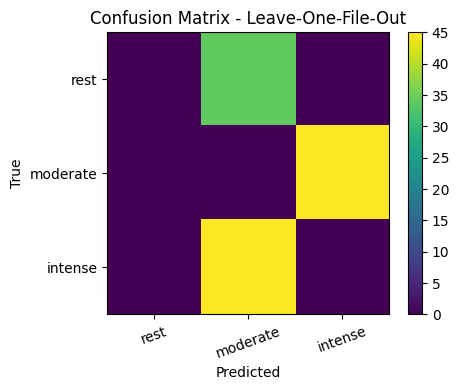

In [30]:
cm = confusion_matrix(all_true, all_preds)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Leave-One-File-Out")
plt.colorbar()
plt.xticks([0, 1, 2], ["rest", "moderate", "intense"], rotation=20)
plt.yticks([0, 1, 2], ["rest", "moderate", "intense"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("../data/processed/strict_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 8) Feature importance

emg_env_mean     0.138127
ax_std           0.087099
ay_std           0.083797
az_std           0.063653
jerk_mean        0.054244
acc_mag_std      0.049933
jerk_std         0.049480
emg_rms          0.048679
acc_mag_max      0.047768
emg_mav          0.046505
emg_raw_mean     0.044488
acc_mag_range    0.041049
ax_min           0.035503
ax_mean          0.031125
temp_mean        0.028555
temp_max         0.023170
temp_min         0.022427
emg_raw_std      0.022093
ay_mean          0.014550
ay_max           0.009744
dtype: float64


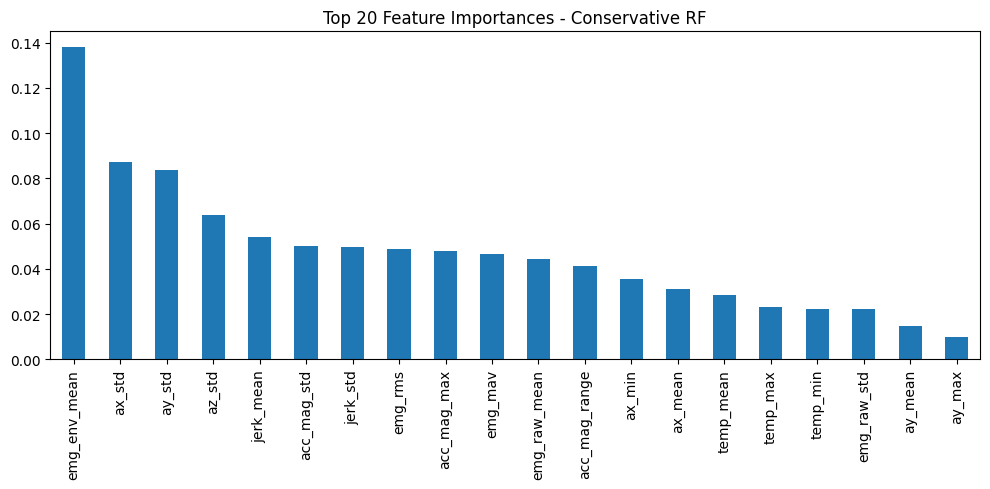

In [25]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced"
)

rf_final.fit(X_all, y_all)

importances = pd.Series(rf_final.feature_importances_, index=X_all.columns).sort_values(ascending=False)

print(importances.head(20))

plt.figure(figsize=(10, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances - Conservative RF")
plt.tight_layout()
plt.show()

## 9) Save outputs

In [26]:
from pathlib import Path
import joblib

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../models/classical").mkdir(parents=True, exist_ok=True)

features_df.to_csv("../data/processed/activity_fusion_features_sensors_strict.csv", index=False)
joblib.dump(rf_final, "../models/classical/activity_classifier_rf_sensors_conservative.pkl")

print("Saved successfully.")

Saved successfully.


## 10) Strict evaluation reuslts

In [27]:
results_df.to_csv("../data/processed/strict_evaluation_results_by_file.csv", index=False)

cm_df = pd.DataFrame(
    cm,
    index=["true_rest", "true_moderate", "true_intense"],
    columns=["pred_rest", "pred_moderate", "pred_intense"]
)
cm_df.to_csv("../data/processed/strict_confusion_matrix.csv")

importances.to_csv("../data/processed/strict_feature_importance.csv", header=["importance"])

print("Strict evaluation outputs saved.")

Strict evaluation outputs saved.


## Summary text file

In [31]:
with open("../data/processed/strict_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("File-by-file results:\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\nMean leave-one-file-out accuracy:\n")
    f.write(str(results_df["accuracy"].mean()))
    f.write("\n\nClassification report:\n")
    f.write(classification_report(all_true, all_preds, target_names=["rest", "moderate", "intense"]))

print("Saved strict metrics summary.")

Saved strict metrics summary.


C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vPro\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize